In [1]:
"""
Letter decoding with mean‐template classifiers + cross‐session alignment.

Pipeline:
1) Load and precompute shared metadata (letters, sessions, windows).
2) For each bootstrap/permutation:
   a) Build session dictionaries expected by `compute_session_alignment`.
   b) Align sessions into a common subspace.
   c) Project trials and run mean‐template decoding in sliding time windows.
3) Aggregate across permutations and save per‐letter time×time decoding maps.
4) Perform cluster‐based permutation tests and plot significance overlays.

NOTE: This file adds comments and light structure only; algorithmic behavior
remains the same. Look for "TODO" tags on potential issues.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pickle
import glob
import sys

# Make local code importable (expects Code/compute_session_alignment.py)
sys.path.append('./Code/')
import compute_session_alignment

from collections import Counter
from joblib import Parallel, delayed

# ---------------------------------------------------------------------
# Decoders: mean‐template variants
# ---------------------------------------------------------------------
def letter_decoding_mean(x_train, x_test, y_train, y_test, shuffle=False):
    """
    Mean‐template decoding that compares per‐class mean TEST activity to
    per‐class mean TRAIN templates using cosine similarity, but counts
    accuracy at the **class‐mean** level (i.e., 1 correct per class).

    Args
    ----
    x_train, x_test : array (trials × time × features) BEFORE windowing.
    y_train, y_test : array (trials,) with discrete class labels.
    shuffle         : bool, if True shuffles y labels for a null/control.

    Returns
    -------
    score_matrix : (n_win × n_win) array of counts (not normalized).
                   Entry (ti, tj) = number of classes correctly predicted
                   when training a template at window ti and testing on
                   class means at window tj.
    n_classes    : int, number of unique classes present in training labels.
    """
    
    n_win = len(window_ranges)
    score_matrix = np.zeros((n_win, n_win))

    # Copy/alias labels (already integers/strings)
    y_train_encoded = y_train
    y_test_encoded  = y_test
    class_labels    = [0,1] #np.unique(y_train_encoded)

    # Average activity in sliding windows and baseline‐correct by FIX bins
    #print((x_train.shape,x_test.shape),flush=True)
    xTTrain_all = [np.mean(x_train[:, start:end, :], axis=1) #- np.mean(x_train[:, 0:4, :], axis=1)
                   for (start, end) in window_ranges]
    xTTest_all  = [np.mean(x_test[:, start:end, :], axis=1)  #- np.mean(x_test[:, 0:4, :], axis=1)
                   for (start, end) in window_ranges]

    if shuffle:
        # Shuffle labels independently for train/test for a conservative null
        np.random.shuffle(y_train_encoded)
        np.random.shuffle(y_test_encoded)

    all_templates = []  # keep templates from each TRAIN window (for inspection)
    for ti, xTTrain in enumerate(xTTrain_all):
        for tj, xTTest in enumerate(xTTest_all):
            if(ti==tj):
                # --- TRAIN: build one mean template per class (in window ti)
                templates = []
                for c in class_labels:
                    class_indices = np.where(y_train_encoded == c)[0]
                    template = np.mean(xTTrain[class_indices], axis=0)
                    templates.append(template)
                templates = np.array(templates)  # (n_classes × n_features)

                if tj == 0:
                    all_templates.append(templates)

                # --- TEST: compare per‐class MEAN test activity to templates
                correct = 0
                for c_idx, c in enumerate(class_labels):
                    test_indices = np.where(y_test_encoded == c)[0]
                    if len(test_indices) == 0:
                        continue

                    # mean vector for THIS class/window
                    test_vec = np.mean(xTTest[test_indices], axis=0)

                    # Cosine similarity to each template -> scalars
                    corrs = [
                        float(np.dot(test_vec, tpl) / (np.linalg.norm(test_vec) * np.linalg.norm(tpl) + 1e-8))
                        for tpl in templates
                    ]

                    # tie-break
                    if len(corrs) == 2 and np.isclose(corrs[0], corrs[1]):
                        predicted_class_idx = np.random.choice([0, 1])
                    else:
                        predicted_class_idx = int(np.argmax(corrs))

                    predicted_class = class_labels[predicted_class_idx]
                    if predicted_class == c:
                        correct += 1
                        

            score_matrix[ti, tj] = correct  # raw count (not %)
            
    return score_matrix, 2, #len(class_labels)

In [2]:
units = np.load('../Data/units.npy',allow_pickle=True)
units[6][0]

array(['uAHL1_0', 'uAHL1_4', 'uAHL1_5', 'uAHL2_0', 'uAHL3_0', 'uAHL4_1',
       'uAHL5_0', 'uAHL7_1', 'uAHL7_4', 'uAL8_17', 'uAL8_19', 'uECL3_14',
       'uPHL2_3', 'uPHR1_1', 'uPHR3_5', 'uPHR5_1', 'uPHR6_2', 'uPHR6_4',
       'uPHR6_5', 'uPHR6_6', 'uPHR6_7', 'uPHR6_8', 'uPHR6_9', 'uPHR7_16',
       'uPHR7_2', 'uPHR7_3', 'uPHR7_8'], dtype=object)

In [3]:
completeBinned = np.load('../Data/binned.npy', allow_pickle=True)
completeBinned[1].shape

(99, 16, 16)

In [4]:
letters        = np.load('../Data/letters.npy')
uniqueLetters = np.array([p for p in np.unique(letters) if p not in ['Q', 'W', 'X']])
uniqueLetters

array(['B', 'C', 'D', 'F', 'G', 'H', 'K', 'L', 'N', 'P', 'R', 'S', 'T',
       'V', 'Z'], dtype='<U1')

In [5]:
subj_ses = np.load('../Data/subjs_sep.npy',allow_pickle=True)
len(subj_ses)

35

In [6]:
from copy import deepcopy
NPC_TO_ALIGN = 5
# ---------------------------------------------------------------------
# Shared/static variables (loaded once)
# ---------------------------------------------------------------------
# NOTE: The following variables are referenced later. Make sure they are
# defined prior to calling functions that use them.

# Load all data (paths assume ../Data/ exists)
probes         = np.load('../Data/probes.npy')
subj           = np.load('../Data/subjs.npy')
subj_ses       = np.load('../Data/subjs_sep.npy', allow_pickle=True)
inout          = np.load('../Data/in.npy')
letters        = np.load('../Data/letters.npy')
letters_ses    = np.load('../Data/letters_sep.npy', allow_pickle=True)
probes_ses     = np.load('../Data/probes_sep.npy', allow_pickle=True)
units          = np.load('../Data/units.npy',allow_pickle=True)

# Subject/session metadata
sses          = [s[0] for s in subj_ses]
uniqueSub     = np.unique(sses)

# Letters (exclude rarely used or unwanted letters)
uniqueLetters = np.array([p for p in np.unique(letters) if p not in ['Q', 'W', 'X']])
n_labels      = len(uniqueLetters)

# Sliding windows: 4 bins wide, sliding by 1 bin (29 positions)
window_ranges = [(i, i + 1) for i in range(16)]

# ---------------------------------------------------------------------
# One permutation "trial": align, project, decode (for one letter)
# ---------------------------------------------------------------------
t1 = 2
t2 = 16
def single_trial(ktrial, letter_index):
    retry = 0 
    ok = False
    while not ok:
        maskSub = [subj_ses[i][0]!=outSub for i in range(len(subj_ses))]
        completeBinned = np.load('../Data/binned.npy', allow_pickle=True)
        completeBinned = completeBinned[maskSub]
        #Counter(subj)

        data = []
        train_test_labels = []

        Y      = [np.array([[1 if u in letterString else 0 for u in uniqueLetters] for letterString in ls], dtype=int)
                 for ls in letters_ses[maskSub]]
        
        Yprobe = [np.array([[1 if u in letterString else 0 for u in uniqueLetters] for letterString in ls], dtype=int)
                 for ls in probes_ses[maskSub]]
         
        maskSET_TEST  = [np.sum(yi,axis=1)>0 for yi in Y]
        maskSET_TRAIN = [np.sum(yi,axis=1)>0 for yi in Y]
        
        #maskSET_TEST  = [np.sum(yi*yp,axis=1)>=0 for (yi,yp) in zip(Y,Yprobe)]
        #maskSET_TRAIN = [np.sum(yi*yp,axis=1)>=0 for (yi,yp) in zip(Y,Yprobe)]
        #print(maskSET_TEST,flush=True)
        
        units =  np.load('../Data/units.npy', allow_pickle=True)
        units = units[maskSub]

        all_maskU = []
        newcompleteBinned = []
        newY = []
        newMaskSET_TEST  = []
        newMaskSET_TRAIN = []
        for i in range(len(completeBinned)):
            
            maskU = [list(np.where(['R' in ui for ui in units[i][0]])[0])+
            #list(np.where(['AHL' in ui for ui in units[i][0]])[0])+
            #list(np.where(['PHR' in ui for ui in units[i][0]])[0])+
            list(np.where(['L' in ui for ui in units[i][0]])[0])][0]
            
            
            bst = completeBinned[i]
            #print(bst.shape,flush=True)
            #print(maskU,flush=True)
            
            bst = bst[:,maskU]
            bst = np.transpose(bst, (1, 2, 0))
            if len(bst) >= NPC_TO_ALIGN:
                newcompleteBinned.append(completeBinned[i])
                newY.append(Y[i])
                newMaskSET_TEST.append(maskSET_TEST[i])
                newMaskSET_TRAIN.append(maskSET_TRAIN[i])
                tt_label  = np.random.uniform(0, 1, len(bst[0][0])) > 0.5
                #tt_label = np.zeros(len(bst[0][0]))
                #tt_label[np.random.choice(np.arange(len(tt_label)),
                #                          size=1,
                #                          replace=False)] = 1

                condition = Y[i][:, letter_index]

                mask    = np.logical_and(tt_label == 0,condition>-1)
                timeB   = np.arange(len(bst[0])) * 0.250
                session = {
                    'response' : bst[:,:,mask],#bst[:, :, tt_label == 0],
                    'condition': condition[mask],#condition[tt_label == 0],
                    'time'     : timeB
                }
                data.append(session)
                all_maskU.append(maskU)
                train_test_labels.append(tt_label)


        pars = {'alignment': {'nPCs_align': NPC_TO_ALIGN, 'cond_contrast': (1, 0)}, 'align_proj': {'condition_vars': []}}

        D_align, D_cond_avg_proj_align, align_stats = compute_session_alignment.compute_session_alignment_CONTRAST_2BIAS(data, [], pars,t1,t2)

        Z_align = deepcopy(D_align)
        #print(len(all_maskU),len(train_test_labels),len(newcompleteBinned),len(D_align),newcompleteBinned[0].shape,flush=True)
        X = np.concatenate([Z_align[i]['response'] for i in range(len(Z_align))], axis=2)
        #X = X[accepted_components]
        projected_X = [
            np.transpose(newcompleteBinned[sesID][:,all_maskU[sesID]], (0, 2, 1)) @ D_align[sesID]['U'] + D_align[sesID]['bias'] #[:, accepted_components]
            for sesID in range(len(newcompleteBinned))
        ]

        #print(len(projected_X),flush=True)
        X_train = [projected_X[i][np.logical_and(train_test_labels[i] == 0, newMaskSET_TRAIN[i])] for i in range(len(train_test_labels))]
        X_test  = [projected_X[i][np.logical_and(train_test_labels[i] == 1, newMaskSET_TEST[i])] for i in range(len(train_test_labels))]
        Y_train = [newY[i][np.logical_and(train_test_labels[i] == 0, newMaskSET_TRAIN[i]), letter_index] for i in range(len(train_test_labels))]
        Y_test  = [newY[i][np.logical_and(train_test_labels[i] == 1, newMaskSET_TEST[i]), letter_index] for i in range(len(train_test_labels))]
        #Y_probe_test  = [Yprobe[i][train_test_labels[i] == 1, letter_index] for i in range(len(train_test_labels))]

        X_train = np.concatenate(X_train, axis=0)
        X_test  = np.concatenate(X_test, axis=0)
        Y_train = np.concatenate(Y_train, axis=0)
        Y_test  = np.concatenate(Y_test, axis=0)
        
        if( (np.sign(np.mean(X_train[Y_train==1,t1:t2]))*np.sign(np.mean(X_train[Y_train==0,t1:t2])))<0 ):
            ok = True
        else:
            print('retry attempt: ',retry,flush=True)
            retry += 1
    
    
    MW,SUM_IT = letter_decoding_mean(
            X_train,
            X_test,
            Y_train,
            Y_test,
            shuffle=True
        )

    #return [D_align[sesID]['U'] + D_align[sesID]['bias'] for sesID in range(len(completeBinned))]
    return MW,SUM_IT

In [ ]:
import importlib
importlib.reload(compute_session_alignment)
# ---------------------------------------------------------------------
# Outer loops: run multiple rounds and save per‐letter maps
# ---------------------------------------------------------------------
print(np.unique(subj))
for outSub in [0]: #np.unique(subj):
    print(outSub)
    for qqq in range(200):
        print(qqq)
        all_Letters = []
        for letter_index in range(15):  # first 15 letters from uniqueLetters
            # Run many permutations in parallel and aggregate
            #print(letter_index)
            c = True
            cc = 0 
            while c:
                try:
                    results = Parallel(n_jobs=-1, verbose=0)(
                    delayed(single_trial)(ktrial, letter_index) for ktrial in range(50)
                    )
                    allMW  = [res[0] for res in results if res is not None]
                    allSUM = [res[1] for res in results if res is not None]
                    mean_MW = np.sum(allMW, axis=0) / np.sum(allSUM)
                    all_Letters.append(mean_MW)
                    c = False
                except:
                    cc +=1
                    #print('Error')
                    if(cc >50):
                        continue

        np.save(f'../single_letter_shuffle_'+str(qqq)+'.npy', all_Letters)

[40 43 44 45 47 53 57 58 61 63 64]
0
0


In [11]:
letter_acc = []
for k in range(50):
    al_real = []
    all_Letters = np.load(f'../../FC_letter_decoding_updated/Results/single_letter_50_{k}.npy')
    for letter_index in range(15):       
        al_real.append(np.diag(all_Letters[letter_index]))
    al_real = np.array(al_real)  # shape: (n_subjects, n_times)
    letter_acc.append(al_real)
letter_acc = np.array(letter_acc)
print(letter_acc.shape)

letter_acc_noLetterNeurons = []
for k in range(50):
    al_real = []
    all_Letters = np.load(f'../Results/single_letter_noLetterNeurons_{k}.npy')
    for letter_index in range(15):       
        al_real.append(np.diag(all_Letters[letter_index]))
    al_real = np.array(al_real)  # shape: (n_subjects, n_times)
    letter_acc_noLetterNeurons.append(al_real)
letter_acc_noLetterNeurons = np.array(letter_acc_noLetterNeurons)
print(letter_acc_noLetterNeurons.shape)


letter_shuffle_acc = []
for k in range(200):
    al_real = []
    all_Letters = np.load(f'../Results/single_letter_shuffle_{k}.npy')
    for letter_index in range(15):       
        al_real.append(np.diag(all_Letters[letter_index]))
    al_real = np.array(al_real)  # shape: (n_subjects, n_times)
    letter_shuffle_acc.append(al_real)
letter_shuffle_acc = np.array(letter_shuffle_acc)
print(letter_shuffle_acc.shape)

(50, 15, 16)
(50, 15, 16)
(200, 15, 16)


In [14]:
L = min(15, len(uniqueLetters))
T1 = 2
T2 = 16
T = T2 - T1

# True accuracies per letter across runs at the last cumulative step
last_true = np.median(np.array([
    np.cumsum(letter_acc[:, i, T1:T2], axis=-1)[:, -1] / T
    for i in range(L)
]),axis=-1)  # (L, n_runs_true)

# True accuracies per letter across runs at the last cumulative step
last_true_noLetterNeurons = np.median(np.array([
    np.cumsum(letter_acc_noLetterNeurons[:, i, T1:T2], axis=-1)[:, -1] / T
    for i in range(L)
]),axis=-1)  

from scipy.stats import ttest_rel

t_stat, p_two_sided = ttest_rel(last_true, last_true_noLetterNeurons)

print("Paired t-test across letters")
print("t =", t_stat)
print("p (two-sided) =", p_two_sided)

Paired t-test across letters
t = -0.6792468029747593
p (two-sided) = 0.5080565385858379


In [17]:
last_true.shape

(15,)

Permutation test with vs without (median): stat = -0.004, p = 0.9446


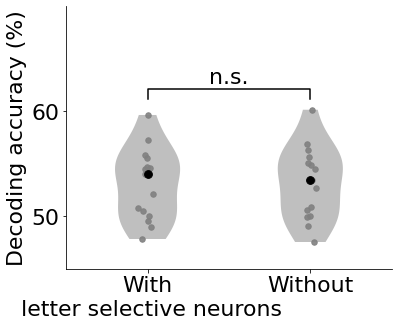

In [19]:
import matplotlib
matplotlib.rcParams.update({'font.size': 22})


dIN  = last_true
dOUT = last_true_noLetterNeurons

# Only compare 4 and 6
data      = [last_true, last_true_noLetterNeurons]
positions = [4, 6]
colors    = ['gray', 'gray']

fig, ax = plt.subplots(figsize=(6, 5))

# For reproducible jitter
rng = np.random.default_rng(0)

for d, pos, color in zip(data, positions, colors):
    # Violin for this set size
    vp = ax.violinplot(d,
                       positions=[pos],
                       widths=0.8,
                       showmeans=False,
                       showmedians=False,
                       showextrema=False)

    # Color the violin
    for body in vp['bodies']:
        body.set_facecolor(color)
        body.set_alpha(0.5)

    # Scatter points on top of the violin
    x_jitter = rng.normal(loc=pos, scale=0.05, size=len(d))
    ax.scatter(x_jitter, d, color=color, s=30, zorder=3, alpha=0.9)

# --- Add median dots in black ---
medians = [np.median(d) for d in data]
ax.scatter(positions, medians, color='black', s=60, zorder=4)

# =========================================================
#      Paired permutation test on MEDIAN difference
#      H1: median(d4 - d6) > 0
# =========================================================

def p_to_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'n.s.'

def permutation_test_paired_median_greater(x, y, n_perm=200000, rng=None):
    """
    One-sided paired permutation test for H1: median(x - y) > 0.

    Test statistic = median(x - y).
    Null is generated by random sign-flips of the paired differences.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    if x.shape != y.shape:
        raise ValueError("x and y must have the same shape for a paired test")

    diff = x - y
    obs_stat = np.median(diff)

    if rng is None:
        rng = np.random.default_rng(1)

    n = diff.size
    # Random sign flips for each permutation
    signs = rng.choice([-1, 1], size=(n_perm, n))
    perm_diffs = np.median(signs * diff, axis=1)

    # One-sided p-value: P(perm_stat >= obs_stat)
    p_value = (np.sum(perm_diffs >= obs_stat) + 1) / (n_perm + 1)

    return obs_stat, p_value

# Non-parametric paired permutation test: 4 vs 6 (H1: d4 > d6)
stat_468, p_468 = permutation_test_paired_median_greater(dIN, dOUT)
print(f"Permutation test with vs without (median): stat = {stat_468:.3f}, p = {p_468:.4g}")

# --- Bracket and stars for 4–68 ---
ymax_data = max([np.max(d) for d in data])
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax_data + 0.05)  # room for bracket

base_y = ymax_data + 0.01      # height for the comparison line
line_h = 0.01                  # small vertical rise for bracket

stars = p_to_stars(p_468)
ax.plot([4, 4, 6, 6],
        [base_y, base_y + line_h, base_y + line_h, base_y],
        lw=1.5, c='black')
ax.text((4 + 6)/2, base_y + line_h + 0.002,
        stars, ha='center', va='bottom')

# Axis formatting
#ax.set_xlabel('Set Size')
ax.set_ylabel('Decoding accuracy (%)')
ax.set_xticks(positions)
ax.set_xticklabels(["With\n letter selective neurons", "Without"])

ax.set_yticks([0.5, 0.6], [50, 60])
ax.set_ylim(0.45, 0.7)
ax.set_xlim(3, 7)   # padding around the violins
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('withWithoutSelectivity.svg', dpi=200)
plt.show()

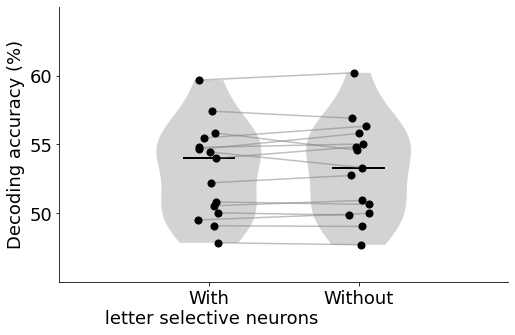

In [35]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
})

# Expect shapes (L,)
a = np.asarray(last_true).ravel()
b = np.asarray(last_true_noLetterNeurons).ravel()
assert a.shape == b.shape, "Both conditions must have same shape (L,)"

L = a.shape[0]

# X positions
x1, x2 = 1, 2

fig, ax = plt.subplots(figsize=(7.5, 5.0))

# Violin plots (gray)
parts = ax.violinplot([a, b],
                      positions=[x1, x2],
                      widths=0.7,
                      showmeans=False,
                      showmedians=True,
                      showextrema=False)

for pc in parts['bodies']:
    pc.set_facecolor("lightgray")
    pc.set_edgecolor("None")
    pc.set_alpha(1.0)

# Median line styling
if 'cmedians' in parts:
    parts['cmedians'].set_color("black")
    parts['cmedians'].set_linewidth(2)

# Jitter for scatter points
rng = np.random.default_rng(0)
jitter = 0.07
xa = x1 + rng.uniform(-jitter, jitter, size=L)
xb = x2 + rng.uniform(-jitter, jitter, size=L)

# Scatter points (black)
ax.scatter(xa, a, s=50, color="black", zorder=3)
ax.scatter(xb, b, s=50, color="black", zorder=3)

# Paired lines connecting each letter (gray)
for i in range(L):
    ax.plot([xa[i], xb[i]],
            [a[i], b[i]],
            color="gray",
            alpha=0.5,
            linewidth=1.5,
            zorder=2)

# Formatting
ax.set_xticks([x1, x2])
ax.set_xticklabels(["With\n letter selective neurons", "Without"])
ax.set_ylabel("Decoding accuracy (%)")

# Y-axis ticks only at 50, 55, 60
ax.set_yticks([0.5,0.55,0.6],[50, 55, 60])
ax.set_ylim(0.45, 0.65)
ax.set_xlim(0,3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig('withwithout_selectivity.svg',dpi=200)
plt.show()

letter  true_mean  true_median  shuffle_mean  shuffle_median  shuffle_p05  shuffle_p95  p_value_percentile  q_value_bh signif
     F   0.596686     0.596429      0.500496        0.501429     0.483429      0.52075            0.009950    0.018657      *
     B   0.574129     0.572500      0.500496        0.501429     0.483429      0.52075            0.009950    0.018657      *
     G   0.558214     0.558571      0.500496        0.501429     0.483429      0.52075            0.009950    0.018657      *
     C   0.554643     0.555000      0.500496        0.501429     0.483429      0.52075            0.009950    0.018657      *
     V   0.547829     0.546786      0.500496        0.501429     0.483429      0.52075            0.009950    0.018657      *
     D   0.546400     0.546071      0.500496        0.501429     0.483429      0.52075            0.009950    0.018657      *
     N   0.544457     0.545000      0.500496        0.501429     0.483429      0.52075            0.009950    0.018657

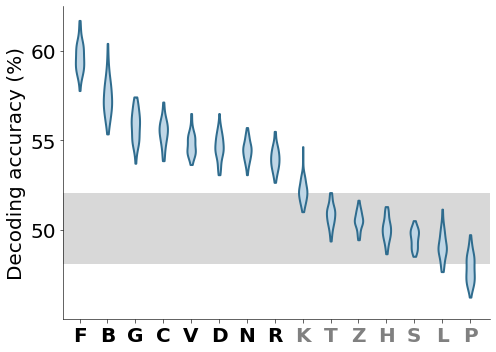

In [13]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patheffects as pe

# ---------- helpers ----------
def benjamini_hochberg(pvals):
    """Return q-values (FDR-adjusted p-values) using the BH procedure."""
    p = np.asarray(pvals, dtype=float)
    m = p.size
    order = np.argsort(p)
    ranked_p = p[order]
    q = np.empty_like(ranked_p)
    prev = 1.0
    for i in range(m - 1, -1, -1):
        q_i = ranked_p[i] * m / (i + 1)
        prev = min(prev, q_i)
        q[i] = prev
    qvals = np.empty_like(q)
    qvals[order] = q
    return qvals

def percentile_pvalue(true_vals, shuffle_vals):
    """
    Two-sided empirical p-value based on the percentile of the TRUE mean
    within the surrogate (SHUFFLE) distribution.

    p = 2 * min( P_shuffle >= true_mean , P_shuffle <= true_mean )
    with +1 smoothing.
    """
    xbar = float(np.median(true_vals))
    s = np.asarray(shuffle_vals, dtype=float)
    n = s.size
    p_ge = (np.sum(s >= xbar) + 1) / (n + 1)
    p_le = (np.sum(s <= xbar) + 1) / (n + 1)
    p_two_sided = 2.0 * min(p_ge, p_le)
    return min(1.0, p_two_sided)

def sig_stars(q):
    if q < 0.001: return '***'
    if q < 0.01:  return '**'
    if q < 0.05:  return '*'
    return ''

# ---------- compute last-step accuracies ----------
# Expects these to already exist in your workspace:
# uniqueLetters
# letter_acc         shape: (n_runs_true,    n_letters, n_steps)
# letter_shuffle_acc shape: (n_runs_shuffle, n_letters, n_steps)

L = min(15, len(uniqueLetters))
T1 = 2
T2 = 16
T = T2 - T1

# True accuracies per letter across runs at the last cumulative step
last_true = np.array([
    np.cumsum(letter_acc[:, i, T1:T2], axis=-1)[:, -1] / T
    for i in range(L)
])  # (L, n_runs_true)

# --------- pooled shuffle across ALL letters ----------
pooled_shuffle = (
    np.cumsum(letter_shuffle_acc[:, :L, T1:T2], axis=-1)[:, :, -1] / T
)#.reshape(-1)  # (n_runs_shuffle * L,)

last_shuffle = np.array([
    np.cumsum(letter_shuffle_acc[:, i, T1:T2], axis=-1)[:, -1] / T
    for i in range(L)
])  # (L, n_runs_true)

# Sort letters by median true accuracy (descending)
order = np.argsort(np.median(last_true, axis=1))[::-1]
ordered_labels = [uniqueLetters[i] for i in order]

# ---------- stats: p-values vs pooled shuffle, BH-FDR correction ----------
pvals = []
for idx in order:
    x_true = last_true[idx]
    x_shuffle = last_shuffle[idx]
    pv = percentile_pvalue(x_true, x_shuffle)
    pvals.append(pv)
pvals = np.asarray(pvals)
qvals = benjamini_hochberg(pvals)

stats_df = pd.DataFrame({
    "letter": ordered_labels,
    "true_mean":   [np.mean(last_true[i])   for i in order],
    "true_median": [np.median(last_true[i]) for i in order],
    "shuffle_mean":   np.mean(pooled_shuffle),
    "shuffle_median": np.median(x_shuffle),
    "shuffle_p05": np.percentile(x_shuffle, 5),
    "shuffle_p95": np.percentile(x_shuffle, 95),
    "p_value_percentile": pvals,
    "q_value_bh": qvals,
    "signif": [sig_stars(q) for q in qvals],
})
print(stats_df.to_string(index=False))

# ---------- simplified Nature Neuroscience figure (clean) ----------
mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.family": "sans-serif",
    "axes.linewidth": 0.6,
    "xtick.direction": "out", "ytick.direction": "out",
    "xtick.major.width": 0.6, "ytick.major.width": 0.6
})

figsize = (7, 5)
FS = 20

COL_TRUE   = "#2F6C8E"
COL_TRUE_L = "#BFD6E6"

# Band settings (neutral gray)
COL_BAND = "#BFBFBF"
COL_BAND_EDGE = "#7A7A7A"

fig, ax = plt.subplots(figsize=figsize)

delta = 0 # 0.18
positions_true = np.arange(L) - delta

data_true = [last_true[i] for i in order]

# --- pooled shuffle band: 5–95 percentile ---
p05 = np.percentile(pooled_shuffle, 5)
p95 = np.percentile(pooled_shuffle, 95)
p50 = np.percentile(pooled_shuffle, 50)

# Make band span across full x-range of the plotted categories
x_left = -0.6
x_right = (L - 1) + 0.7

ax.fill_between([x_left, x_right], [p05, p05], [p95, p95],
                alpha=0.6, linewidth=0, facecolor=COL_BAND, zorder=0)

# Optional: median line of pooled shuffle
#ax.plot([x_left, x_right], [p50, p50], linewidth=1.5, color=COL_BAND_EDGE, zorder=1)

# --- True violins ---
vp_true = ax.violinplot(
    data_true, positions=positions_true,
    widths=0.30, showextrema=False, showmedians=False, showmeans=False
)
for body in vp_true["bodies"]:
    body.set_facecolor(COL_TRUE_L)
    body.set_edgecolor(COL_TRUE)
    body.set_linewidth(2.0)
    body.set_alpha(1)

# --- Significance stars (computed vs pooled shuffle) ---
y_max = np.array([max(np.max(t), p95) for t in data_true])
y_pad = 0.04 * (np.max(y_max) - np.min(y_max))
for xt, q, ymax in zip(positions_true, qvals, y_max):
    stars = sig_stars(q)
    # ax.text(xt, ymax + y_pad, stars, ha="center", va="bottom",
    #         fontsize=FS, color="black")

# Your black lines
#plt.plot([0, 7.5], [0.46, 0.46], color="k", linewidth=4,
#         path_effects=[pe.Stroke(linewidth=2, foreground="k"), pe.Normal()])
#w1 = 0.001
#plt.plot([7.5, 15.5], [0.46 - w1, 0.46 - w1], color="k", linewidth=1)
#w2 = -0.0005
#plt.plot([7.5, 15.5], [0.46 - w2, 0.46 - w2], color="k", linewidth=1)

# Cosmetics
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(x_left, x_right)
ax.set_ylim(0.450, 0.625)
ax.set_ylabel("Decoding accuracy (%)", fontsize=20)
ax.set_xticks(np.arange(L))
ax.set_xticklabels(ordered_labels, rotation=0, ha="center", fontsize=FS)

xticks = ax.get_xticklabels()
for i, label in enumerate(xticks):
    label.set_fontweight("bold")
    label.set_color("black" if i < 8 else "gray")

ax.set_yticks([0.5, 0.55, 0.6], [50, 55, 60], fontsize=FS)
ax.tick_params(labelsize=FS)

plt.subplots_adjust(bottom=0.15, top=0.92, left=0.10, right=0.995)
plt.tight_layout()
plt.savefig('figure_letters.svg',dpi=200)
plt.show()

#fig.savefig("../figure_letters.png", dpi=200)

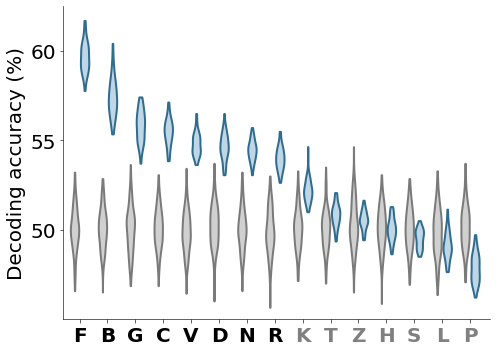

In [17]:
# ---------- simplified Nature Neuroscience figure (clean) ----------
mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.family": "sans-serif",
    "axes.linewidth": 0.6,
    "xtick.direction": "out", "ytick.direction": "out",
    "xtick.major.width": 0.6, "ytick.major.width": 0.6
})

figsize = (7, 5)
FS = 20

COL_TRUE   = "#2F6C8E"
COL_TRUE_L = "#BFD6E6"

# Shuffle violin colors (gray)
COL_SHUF   = "#7A7A7A"
COL_SHUF_L = "#D0D0D0"

fig, ax = plt.subplots(figsize=figsize)

# ---- positions: shuffle slightly left, true slightly right (or vice versa)
delta = 0.18
positions_shuffle = np.arange(L) - delta
positions_true    = np.arange(L) + delta

# Data in display order
data_true    = [last_true[i]    for i in order]
data_shuffle = [last_shuffle[i] for i in order]

# --- Shuffle violins (one per letter) ---
vp_shuf = ax.violinplot(
    data_shuffle, positions=positions_shuffle,
    widths=0.30, showextrema=False, showmedians=False, showmeans=False
)
for body in vp_shuf["bodies"]:
    body.set_facecolor(COL_SHUF_L)
    body.set_edgecolor(COL_SHUF)
    body.set_linewidth(2.0)
    body.set_alpha(1.0)

# --- True violins ---
vp_true = ax.violinplot(
    data_true, positions=positions_true,
    widths=0.30, showextrema=False, showmedians=False, showmeans=False
)
for body in vp_true["bodies"]:
    body.set_facecolor(COL_TRUE_L)
    body.set_edgecolor(COL_TRUE)
    body.set_linewidth(2.0)
    body.set_alpha(1.0)

# --- Significance stars (computed vs per-letter shuffle; keep your qvals as-is) ---
# (optional) place relative to each letter's max across both violins
y_max = np.array([max(np.max(t), np.max(s)) for t, s in zip(data_true, data_shuffle)])
y_pad = 0.04 * (np.max(y_max) - np.min(y_max) + 1e-12)
for xt, q, ymax in zip(np.arange(L), qvals, y_max):
    stars = sig_stars(q)
    # ax.text(xt, ymax + y_pad, stars, ha="center", va="bottom",
    #         fontsize=FS, color="black")

# Cosmetics
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

x_left = -0.6
x_right = (L - 1) + 0.7
ax.set_xlim(x_left, x_right)
ax.set_ylim(0.450, 0.625)

ax.set_ylabel("Decoding accuracy (%)", fontsize=20)
ax.set_xticks(np.arange(L))
ax.set_xticklabels(ordered_labels, rotation=0, ha="center", fontsize=FS)

xticks = ax.get_xticklabels()
for i, label in enumerate(xticks):
    label.set_fontweight("bold")
    label.set_color("black" if i < 8 else "gray")

ax.set_yticks([0.5, 0.55, 0.6], [50, 55, 60], fontsize=FS)
ax.tick_params(labelsize=FS)

plt.subplots_adjust(bottom=0.15, top=0.92, left=0.10, right=0.995)
plt.tight_layout()
plt.show()

In [16]:
from copy import deepcopy
NPC_TO_ALIGN = 5
# ---------------------------------------------------------------------
# Shared/static variables (loaded once)
# ---------------------------------------------------------------------
# NOTE: The following variables are referenced later. Make sure they are
# defined prior to calling functions that use them.

# Load all data (paths assume ../Data/ exists)
probes         = np.load('../Data/probes.npy')
subj           = np.load('../Data/subjs.npy')
subj_ses       = np.load('../Data/subjs_sep.npy', allow_pickle=True)
inout          = np.load('../Data/in.npy')
letters        = np.load('../Data/letters.npy')
letters_ses    = np.load('../Data/letters_sep.npy', allow_pickle=True)
probes_ses     = np.load('../Data/probes_sep.npy', allow_pickle=True)
units          = np.load('../Data/units.npy',allow_pickle=True)

# Subject/session metadata
sses          = [s[0] for s in subj_ses]
uniqueSub     = np.unique(sses)

# Letters (exclude rarely used or unwanted letters)
uniqueLetters = np.array([p for p in np.unique(letters) if p not in ['Q', 'W', 'X']])
n_labels      = len(uniqueLetters)

# Sliding windows: 4 bins wide, sliding by 1 bin (29 positions)
window_ranges = [(i, i + 1) for i in range(16)]

# ---------------------------------------------------------------------
# One permutation "trial": align, project, decode (for one letter)
# ---------------------------------------------------------------------
t1 = 2
t2 = 16
def single_trial(ktrial, letter_index):
    retry = 0 
    ok = False
    while not ok:
        maskSub = [subj_ses[i][0]!=outSub for i in range(len(subj_ses))]
        completeBinned = np.load('../Data/binned.npy', allow_pickle=True)
        completeBinned = completeBinned[maskSub]
        #Counter(subj)

        data = []
        train_test_labels = []

        Y      = [np.array([[1 if u in letterString else 0 for u in uniqueLetters] for letterString in ls], dtype=int)
                 for ls in letters_ses[maskSub]]
        
        Yprobe = [np.array([[1 if u in letterString else 0 for u in uniqueLetters] for letterString in ls], dtype=int)
                 for ls in probes_ses[maskSub]]
         
        maskSET_TEST  = [np.sum(yi,axis=1)>0 for yi in Y]
        maskSET_TRAIN = [np.sum(yi,axis=1)>0 for yi in Y]
        
        #maskSET_TEST  = [np.sum(yi*yp,axis=1)>=0 for (yi,yp) in zip(Y,Yprobe)]
        #maskSET_TRAIN = [np.sum(yi*yp,axis=1)>=0 for (yi,yp) in zip(Y,Yprobe)]
        #print(maskSET_TEST,flush=True)
        
        units =  np.load('../Data/units.npy', allow_pickle=True)
        units = units[maskSub]

        all_maskU = []
        newcompleteBinned = []
        newY = []
        newMaskSET_TEST  = []
        newMaskSET_TRAIN = []
        for i in range(len(completeBinned)):
            
            maskU = [list(np.where(['R' in ui for ui in units[i][0]])[0])+
            #list(np.where(['AHL' in ui for ui in units[i][0]])[0])+
            #list(np.where(['PHR' in ui for ui in units[i][0]])[0])+
            list(np.where(['L' in ui for ui in units[i][0]])[0])][0]
            
            
            bst = completeBinned[i]
            #print(bst.shape,flush=True)
            #print(maskU,flush=True)
            
            bst = bst[:,maskU]
            bst = np.transpose(bst, (1, 2, 0))
            if len(bst) >= NPC_TO_ALIGN:
                newcompleteBinned.append(completeBinned[i])
                newY.append(Y[i])
                newMaskSET_TEST.append(maskSET_TEST[i])
                newMaskSET_TRAIN.append(maskSET_TRAIN[i])
                tt_label  = np.random.uniform(0, 1, len(bst[0][0])) > 0.5
                #tt_label = np.zeros(len(bst[0][0]))
                #tt_label[np.random.choice(np.arange(len(tt_label)),
                #                          size=1,
                #                          replace=False)] = 1

                condition = Y[i][:, letter_index]

                mask    = np.logical_and(tt_label == 0,condition>-1)
                timeB   = np.arange(len(bst[0])) * 0.250
                session = {
                    'response' : bst[:,:,mask],#bst[:, :, tt_label == 0],
                    'condition': condition[mask],#condition[tt_label == 0],
                    'time'     : timeB
                }
                data.append(session)
                all_maskU.append(maskU)
                train_test_labels.append(tt_label)


        pars = {'alignment': {'nPCs_align': NPC_TO_ALIGN, 'cond_contrast': (1, 0)}, 'align_proj': {'condition_vars': []}}

        D_align, D_cond_avg_proj_align, align_stats = compute_session_alignment.compute_session_alignment_CONTRAST_2BIAS(data, [], pars,t1,t2)

        Z_align = deepcopy(D_align)
        #print(len(all_maskU),len(train_test_labels),len(newcompleteBinned),len(D_align),newcompleteBinned[0].shape,flush=True)
        X = np.concatenate([Z_align[i]['response'] for i in range(len(Z_align))], axis=2)
        #X = X[accepted_components]
        projected_X = [
            np.transpose(newcompleteBinned[sesID][:,all_maskU[sesID]], (0, 2, 1)) @ D_align[sesID]['U'] + D_align[sesID]['bias'] #[:, accepted_components]
            for sesID in range(len(newcompleteBinned))
        ]

        #print(len(projected_X),flush=True)
        X_train = [projected_X[i][np.logical_and(train_test_labels[i] == 0, newMaskSET_TRAIN[i])] for i in range(len(train_test_labels))]
        X_test  = [projected_X[i][np.logical_and(train_test_labels[i] == 1, newMaskSET_TEST[i])] for i in range(len(train_test_labels))]
        Y_train = [newY[i][np.logical_and(train_test_labels[i] == 0, newMaskSET_TRAIN[i]), letter_index] for i in range(len(train_test_labels))]
        Y_test  = [newY[i][np.logical_and(train_test_labels[i] == 1, newMaskSET_TEST[i]), letter_index] for i in range(len(train_test_labels))]
        #Y_probe_test  = [Yprobe[i][train_test_labels[i] == 1, letter_index] for i in range(len(train_test_labels))]

        X_train = np.concatenate(X_train, axis=0)
        X_test  = np.concatenate(X_test, axis=0)
        Y_train = np.concatenate(Y_train, axis=0)
        Y_test  = np.concatenate(Y_test, axis=0)
        
        if( (np.sign(np.mean(X_train[Y_train==1,t1:t2]))*np.sign(np.mean(X_train[Y_train==0,t1:t2])))<0 ):
            ok = True
        else:
            print('retry attempt: ',retry,flush=True)
            retry += 1
    
    
    MW,SUM_IT = letter_decoding_mean(
            X_train,
            X_test,
            Y_train,
            Y_test,
            shuffle=True
        )

    return [D_align[sesID]['U'] + D_align[sesID]['bias'] for sesID in range(len(completeBinned))]
    #return MW,SUM_IT

In [22]:
import importlib
importlib.reload(compute_session_alignment)
# ---------------------------------------------------------------------
# Outer loops: run multiple rounds and save per‐letter maps
# ---------------------------------------------------------------------
print(np.unique(subj))
for outSub in [0]: #np.unique(subj):
    print(outSub)
    for qqq in range(10):
        print(qqq)
        allAXES = []
        for letter_index in range(15):  # first 15 letters from uniqueLetters
            # Run many permutations in parallel and aggregate
            #print(letter_index)
            c = True
            cc = 0 
            while c:
                try:
                    results = Parallel(n_jobs=-1, verbose=0)(
                    delayed(single_trial)(ktrial, letter_index) for ktrial in range(100)
                    )
                    allAXES.append(results)
                    c = False
                except:
                    cc +=1
                    #print('Error')
                    if(cc >50):
                        continue

        np.save(f'../single_letter_axes_'+str(qqq)+'.npy', np.array(allAXES,dtype=object))

[40 43 44 45 47 53 57 58 61 63 64]
0
1
2
3
4
5
6
7
8
9


In [11]:
allAXES = np.load(f'../single_letter_axes_'+str(0)+'.npy',allow_pickle=True)

In [12]:
for sesID in range(35):
    letterAXES = np.array([
        np.mean([allAXES[letterID][i][sesID] for i in range(len(allAXES[letterID]))], axis=0)
        for letterID in range(15)
    ])[:, :, 0]  # shape: (15, n_neurons)

    n_units = letterAXES.shape[1]
    rank = np.linalg.matrix_rank(letterAXES)

    note = ''
    if rank < 15:
        note = f'  ← rank==n_units ({n_units})' if rank == n_units else f'  ← LOW (n_units={n_units})'
    print(f"Session {sesID}: rank={rank}{note}")

Session 0: rank=14  ← rank==n_units (14)
Session 1: rank=15
Session 2: rank=15
Session 3: rank=15
Session 4: rank=15
Session 5: rank=15
Session 6: rank=15
Session 7: rank=15
Session 8: rank=15
Session 9: rank=15
Session 10: rank=15
Session 11: rank=15
Session 12: rank=15
Session 13: rank=15
Session 14: rank=15
Session 15: rank=15
Session 16: rank=15
Session 17: rank=15
Session 18: rank=15
Session 19: rank=15
Session 20: rank=15
Session 21: rank=11  ← rank==n_units (11)
Session 22: rank=15
Session 23: rank=15
Session 24: rank=15
Session 25: rank=15
Session 26: rank=15
Session 27: rank=15
Session 28: rank=15
Session 29: rank=15
Session 30: rank=15
Session 31: rank=12  ← rank==n_units (12)
Session 32: rank=12  ← rank==n_units (12)
Session 33: rank=12  ← rank==n_units (12)
Session 34: rank=14  ← rank==n_units (14)


In [26]:
LETTERS = ['B','C','D','F','G','H','K','L','N','P','R','S','T','V','Z']

# German letter name IPA transcriptions:
# B=/beː/ C=/tseː/ D=/deː/ F=/ɛf/  G=/ɡeː/ H=/haː/ K=/kaː/
# L=/ɛl/  N=/ɛn/  P=/peː/ R=/ɛr/  S=/ɛs/  T=/teː/ V=/faʊ/ Z=/tsɛt/

FEAT_NAMES = [
    'voiced',         #  0
    'bilabial',       #  1
    'labiodental',    #  2
    'alveolar',       #  3
    'velar',          #  4
    'glottal',        #  5  ← H = /h/ in German
    'affricate',      #  6
    'fricative',      #  7
    'nasal',          #  8
    'stop',           #  9
    'lateral',        # 10  ← /l/
    'trill',          # 11  ← German /r/
    'vowel_onset',    # 12: name starts with /ɛ/ (F L N R S)
    'rhyme_ee',       # 13: /eː/ coda — B C D G P T
    'rhyme_aa',       # 14: /aː/ coda — H K
    'rhyme_eps',      # 15: /ɛ_/ coda — F L N R S Z
    'rhyme_au',       # 16: /aʊ/ coda — V (unique)
]

# Rows: B C D F G H K L N P R S T V Z
# Cols: [voiced, bilabial, labiodental, alveolar, velar, glottal,
#        affricate, fricative, nasal, stop, lateral, trill,
#        vowel_onset, rhyme_ee, rhyme_aa, rhyme_eps, rhyme_au]
FEAT_MATRIX = np.array([
 # B  /beː/ — voiced bilabial stop, rhyme /eː/
 [1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
 # C  /tseː/ — voiceless alveolar affricate /ts/, rhyme /eː/
 [0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
 # D  /deː/ — voiced alveolar stop, rhyme /eː/
 [1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
 # F  /ɛf/ — vowel-initial; coda = voiceless labiodental fricative, rhyme /ɛ_/
 [0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0],
 # G  /ɡeː/ — voiced velar stop, rhyme /eː/
 [1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
 # H  /haː/ — voiceless glottal fricative, rhyme /aː/
 [0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0],
 # K  /kaː/ — voiceless velar stop, rhyme /aː/
 [0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0],
 # L  /ɛl/ — vowel-initial; coda = voiced alveolar lateral, rhyme /ɛ_/
 [1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0],
 # N  /ɛn/ — vowel-initial; coda = voiced alveolar nasal, rhyme /ɛ_/
 [1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0],
 # P  /peː/ — voiceless bilabial stop, rhyme /eː/
 [0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
 # R  /ɛr/ — vowel-initial; coda = voiced alveolar/uvular trill, rhyme /ɛ_/
 [1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0],
 # S  /ɛs/ — vowel-initial; coda = voiceless alveolar fricative, rhyme /ɛ_/
 [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0],
 # T  /teː/ — voiceless alveolar stop, rhyme /eː/
 [0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
 # V  /faʊ/ — voiceless labiodental fricative, unique rhyme /aʊ/
 [0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1],
 # Z  /tsɛt/ — voiceless alveolar affricate /ts/, rhyme /ɛ_/
 [0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
], dtype=float)

# ── Pairwise cosine similarity ──────────────────────────────────────────
norms     = np.linalg.norm(FEAT_MATRIX, axis=1, keepdims=True)
FEAT_NORM = FEAT_MATRIX / norms
COS_SIM   = FEAT_NORM @ FEAT_NORM.T

LETTER_IDX = {l: i for i, l in enumerate(LETTERS)}

sim_df = pd.DataFrame(np.round(COS_SIM, 3), index=LETTERS, columns=LETTERS)
print('German IPA pairwise cosine similarity:')
print(sim_df)

print('\nSanity checks:')
print(f'  C-Z (both /ts/ affricate): {COS_SIM[LETTER_IDX["C"],LETTER_IDX["Z"]]:.3f}  <- expect HIGH')
print(f'  H-K (both /aː/ rhyme):     {COS_SIM[LETTER_IDX["H"],LETTER_IDX["K"]]:.3f}  <- expect MED')
print(f'  B-P (voicing pair, /eː/):  {COS_SIM[LETTER_IDX["B"],LETTER_IDX["P"]]:.3f}  <- expect HIGH')
print(f'  V-B (nothing in common):   {COS_SIM[LETTER_IDX["V"],LETTER_IDX["B"]]:.3f}  <- expect 0')
print(f'  B-G (voiced stops, /eː/):  {COS_SIM[LETTER_IDX["B"],LETTER_IDX["G"]]:.3f}')

German IPA pairwise cosine similarity:
       B      C      D      F      G      H      K      L      N      P  \
B  1.000  0.289  0.750  0.000  0.750  0.000  0.289  0.224  0.224  0.866   
C  0.289  1.000  0.577  0.000  0.289  0.000  0.000  0.258  0.258  0.333   
D  0.750  0.577  1.000  0.000  0.750  0.000  0.289  0.447  0.447  0.577   
F  0.000  0.000  0.000  1.000  0.000  0.289  0.000  0.447  0.447  0.000   
G  0.750  0.289  0.750  0.000  1.000  0.000  0.577  0.224  0.224  0.577   
H  0.000  0.000  0.000  0.289  0.000  1.000  0.333  0.000  0.000  0.000   
K  0.289  0.000  0.289  0.000  0.577  0.333  1.000  0.000  0.000  0.333   
L  0.224  0.258  0.447  0.447  0.224  0.000  0.000  1.000  0.800  0.000   
N  0.224  0.258  0.447  0.447  0.224  0.000  0.000  0.800  1.000  0.000   
P  0.866  0.333  0.577  0.000  0.577  0.000  0.333  0.000  0.000  1.000   
R  0.224  0.258  0.447  0.447  0.224  0.000  0.000  0.800  0.800  0.000   
S  0.000  0.289  0.250  0.750  0.000  0.289  0.000  0.671  0.

In [35]:
from scipy.stats import spearmanr, pearsonr
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np

triu_idx = np.triu_indices(15, k=1)
phon_sim_vec = COS_SIM[triu_idx]  # shape: (105,)

results = []

for sesID in range(35):
    letterAXES_ses = np.array([
        np.mean([allAXES[letterID][i][sesID] for i in range(len(allAXES[letterID]))], axis=0)
        for letterID in range(15)
    ])[:, :, 0]

    norms = np.linalg.norm(letterAXES_ses, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1, norms)
    axes_norm = letterAXES_ses / norms

    neural_cos = axes_norm @ axes_norm.T
    neural_sim_vec = neural_cos[triu_idx]

    r_sp, p_sp = spearmanr(phon_sim_vec, neural_sim_vec)
    r_pe, p_pe = pearsonr(phon_sim_vec, neural_sim_vec)

    results.append({
        'session':    sesID,
        'spearman_r': r_sp,
        'spearman_p': p_sp,
        'n_units':    letterAXES_ses.shape[1],
    })

res_df = pd.DataFrame(results)

# ── Multiple comparisons correction (across 35 sessions) ────────────────
for method, label in [('fdr_bh', 'fdr_bh'), ('bonferroni', 'bonf')]:
    _, p_corr, _, _ = multipletests(res_df['spearman_p'], method=method)
    res_df[f'spearman_p_{label}'] = p_corr

res_df['spearman_sig_unc']   = res_df['spearman_p']     < 0.05
res_df['spearman_sig_fdr']   = res_df['spearman_p_fdr_bh'] < 0.05

# ── Print ────────────────────────────────────────────────────────────────
cols = ['session', 'n_units', 'spearman_r', 'spearman_p',
        'spearman_p_fdr_bh', 'spearman_p_bonf',
        'spearman_sig_unc', 'spearman_sig_fdr']
print(res_df[cols].to_string(index=False, float_format='%.3f'))

print(f"\nSessions p<0.05 — uncorrected : {res_df['spearman_sig_unc'].sum()}/35")
print(f"Sessions p<0.05 — FDR (BH)    : {res_df['spearman_sig_fdr'].sum()}/35")
print(f"\nMean Spearman r = {res_df['spearman_r'].mean():.3f}  "
      f"[{res_df['spearman_r'].min():.3f}, {res_df['spearman_r'].max():.3f}]")

# ── Aggregate test: is mean r > 0 across sessions? ───────────────────────
from scipy.stats import ttest_1samp
# Fisher-z transform before averaging
z = np.arctanh(res_df['spearman_r'].clip(-0.9999, 0.9999))
t, p_agg = ttest_1samp(z, popmean=0)
print(f"\nAggregate one-sample t-test on Fisher-z(ρ):")
print(f"  t({len(z)-1}) = {t:.3f},  p = {p_agg:.4f}")

 session  n_units  spearman_r  spearman_p  spearman_p_fdr_bh  spearman_p_bonf  spearman_sig_unc  spearman_sig_fdr
       0       14      -0.043       0.667              0.884            1.000             False             False
       1       16      -0.046       0.640              0.884            1.000             False             False
       2       15       0.190       0.053              0.884            1.000             False             False
       3       31      -0.100       0.310              0.884            1.000             False             False
       4       29       0.087       0.379              0.884            1.000             False             False
       5       33      -0.062       0.530              0.884            1.000             False             False
       6       27       0.298       0.002              0.072            0.072              True             False
       7       19       0.045       0.647              0.884            1.000           